In [66]:
from physics.hstar import gghzz, c6
from physics.simulation import msq
from physics.hzz import zpair, kinematics
from nn.carl import model, dataset

import json
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import hist
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [67]:
SEED=373485

BASE_SIZE=100000

OUTPUT_DIR='jobs/carl/gpudev-one-nonprm'
CONF_FILE='carl-config.json'
SCALER_CONF='scaler.json'
SAMPLE_DIR='..'

In [68]:
with open(os.path.join(OUTPUT_DIR, CONF_FILE), 'r') as conf_file:
    config = json.load(conf_file)

In [69]:
component_1, component_2 = dataset.get_components(config)
c6_given = 'c6_values' in config

sample_sig = gghzz.Process(component_1, (0.1, os.path.join(SAMPLE_DIR, 'ggZZ2e2m_sig.csv'), BASE_SIZE*1.2))
sample_bkg = gghzz.Process(component_2, (1.6, os.path.join(SAMPLE_DIR, 'ggZZ2e2m_bkg.csv'), BASE_SIZE*1.2))

bkg_null_filter = msq.MSQFilter('msq_bkg_sm', value=0.0)
bkg_nan_filter = msq.MSQFilter('msq_bkg_sm', value=np.nan)

z_candidate = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZMasses(bounds1 = (70,115), bounds2 = (70,115))

angles = kinematics.AngularVariables()
four_lepton = kinematics.FourLeptonSystem()

events_training_sig, events_validation_sig = sample_sig.events.filter(bkg_null_filter).filter(bkg_nan_filter).calculate(z_candidate).filter(z_masses).calculate(angles).calculate(four_lepton)[:BASE_SIZE].shuffle(random_state=SEED).split(training=0.5, validation=0.5)
evt_train_sig_to_bkg, evt_val_sig_to_bkg = sample_sig[component_2].filter(bkg_null_filter).filter(bkg_nan_filter).calculate(z_candidate).filter(z_masses).calculate(angles).calculate(four_lepton)[:BASE_SIZE].shuffle(random_state=SEED).split(training=0.5, validation=0.5)

events_training_bkg, events_validation_bkg = sample_bkg.events.filter(bkg_null_filter).filter(bkg_nan_filter).calculate(z_candidate).filter(z_masses).calculate(angles).calculate(four_lepton)[:BASE_SIZE].shuffle(random_state=SEED).split(training=0.5, validation=0.5)
evt_train_bkg_to_sig, evt_val_bkg_to_sig = sample_bkg[component_1].filter(bkg_null_filter).filter(bkg_nan_filter).calculate(z_candidate).filter(z_masses).calculate(angles).calculate(four_lepton)[:BASE_SIZE].shuffle(random_state=SEED).split(training=0.5, validation=0.5)

In [83]:
kin_variables = ['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']

kinematics_training_sig = events_training_sig.kinematics[kin_variables].to_numpy()
kinematics_validation_sig = events_validation_sig.kinematics[kin_variables].to_numpy()

kinematics_training_bkg = events_training_bkg.kinematics[kin_variables].to_numpy()
kinematics_validation_bkg = events_validation_bkg.kinematics[kin_variables].to_numpy()

if c6_given:
    c6_mod_training = c6.Modifier(baseline=component_1, events=events_training_sig, c6_values=[-5,-1,0,1,5])
    _, sig_probabilities_training = c6_mod_training.modify(c6=config['c6_values'])

    c6_mod_validation = c6.Modifier(baseline=component_1, events=events_validation_sig, c6_values=[-5,-1,0,1,5])
    _, sig_probabilities_validation = c6_mod_validation.modify(c6=config['c6_values'])

    c6_mod_training_bkg = c6.Modifier(baseline=component_2, events=evt_train_bkg_to_sig, c6_values=[-5,-1,0,1,5])
    _, bgk_to_sig_prob_training = c6_mod_training.modify(c6=config['c6_values'])

    c6_mod_validation_bkg = c6.Modifier(baseline=component_2, events=evt_val_bkg_to_sig, c6_values=[-5,-1,0,1,5])
    _, bgk_to_sig_prob_validation = c6_mod_validation.modify(c6=config['c6_values'])

    ratios = []

    for sig_prob in sig_probabilities_training:
        ratios.append(sig_probabilities_training/evt_train_sig_to_bkg.probabilities)
        ratios.append(bgk_to_sig_prob_training/events_training_bkg.probabilities)

    ratios = np.array(ratios)
    print(ratios)

else:
    sig_probabilities_training = events_training_sig.probabilities
    sig_probabilities_validation = events_validation_sig.probabilities

    ratios_training = []

    ratios_training.append(events_training_sig.probabilities/evt_train_sig_to_bkg.probabilities)
    ratios_training.append(evt_train_bkg_to_sig.probabilities/events_training_bkg.probabilities)

    ratios_training = np.array(ratios_training)
    ratios_training = ratios_training.reshape(ratios_training.shape[0]*ratios_training.shape[1],)

    ratios_validation = []

    ratios_validation.append(events_validation_sig.probabilities/evt_val_sig_to_bkg.probabilities)
    ratios_validation.append(evt_val_bkg_to_sig.probabilities/events_validation_bkg.probabilities)

    ratios_validation = np.array(ratios_validation)
    ratios_validation = ratios_validation.reshape(ratios_validation.shape[0]*ratios_validation.shape[1],)



train_data = dataset.build_dataset(x_arr_sig = kinematics_training_sig,
                                   x_arr_bkg = kinematics_training_bkg,
                                   signal_probabilities = sig_probabilities_training,
                                   background_probabilities = events_training_bkg.probabilities,
                                   c6_values = config['c6_values'] if c6_given else None)
    
val_data = dataset.build_dataset(x_arr_sig = kinematics_validation_sig,
                                   x_arr_bkg = kinematics_validation_bkg,
                                   signal_probabilities = sig_probabilities_validation,
                                   background_probabilities = events_validation_bkg.probabilities,
                                   c6_values = config['c6_values'] if c6_given else None)

In [76]:
with open(os.path.join(OUTPUT_DIR, SCALER_CONF), 'r') as conf_file:
    scaler_conf = json.load(conf_file)

In [77]:
scaler = MinMaxScaler()
scaler.min_ = scaler_conf['scaler.min_']
scaler.scale_ = scaler_conf['scaler.scale_']

train_set = tf.concat([scaler.transform(train_data[:,:-2]), train_data[:,-2:]], axis=1)
val_set = tf.concat([scaler.transform(val_data[:,:-2]), val_data[:,-2:]], axis=1)

In [78]:
carl_model = model.load(os.path.join(OUTPUT_DIR, 'checkpoint.model.tf'))

In [79]:
predictions_train = carl_model.predict(train_set[:,:-2])
predictions_val = carl_model.predict(val_set[:,:-2])

313/313 [==============================] - 1s 2ms/step


In [84]:
def generate_histograms(data_train, pred_train, data_val, pred_val, num_bins):
    histograms = []

    hist_train = hist.Hist(hist.axis.Regular(num_bins, 0, 1, name='x', label='NN output []'))
    hist_train.fill(tf.squeeze(pred_train, axis=1), weight=data_train[:,-1])

    hist_val = hist.Hist(hist.axis.Regular(num_bins, 0, 1, name='x', label='NN output []'))
    hist_val.fill(tf.squeeze(pred_val, axis=1), weight=data_val[:,-1])

    hist_true = hist.Hist(hist.axis.Regular(num_bins, 0, 1, name='x', label='NN output []'))
    hist_true.fill(ratios_training/(1+ratios_training), weight=data_train[:,-1])

    hist_val_true = hist.Hist(hist.axis.Regular(num_bins, 0, 1, name='x', label='NN output []'))
    hist_val_true.fill(ratios_validation/(1+ratios_validation), weight=data_val[:,-1])

    histograms.append((hist_train.to_numpy(), hist_val.to_numpy(), hist_true.to_numpy(), hist_val_true.to_numpy()))
    
    return histograms

In [85]:
def plot_histograms(c6_values, histograms, colors, xlim=(0.2,0.8)):
    fig = plt.figure(figsize=(7,6))

    for i in range(len(c6_values)):
        plt.step(histograms[i][2][1][1:], histograms[i][2][0], color=colors[i], linestyle='--', label=f'truth (training) (c6={c6_values[i]})', alpha=0.6)
        plt.step(histograms[i][3][1][1:], histograms[i][3][0], color=colors[i+1], linestyle='--', label=f'truth (validation) (c6={c6_values[i]})', alpha=0.6)
        plt.step(histograms[i][0][1][1:], histograms[i][0][0], color=colors[i], label=f'training data (c6={c6_values[i]})', alpha=0.6)
        plt.scatter(histograms[i][1][1][1:], histograms[i][1][0], s=20, color=colors[i+1], label=f'validation data (c6={c6_values[i]})', alpha=0.6)

    plt.xlabel('NN output []')
    plt.ylabel('Percentage of predictions []')
    plt.legend()
    plt.xlim(xlim[0],xlim[1])
    plt.yscale('log')

    plt.show()

(10000,)
(10000, 1)


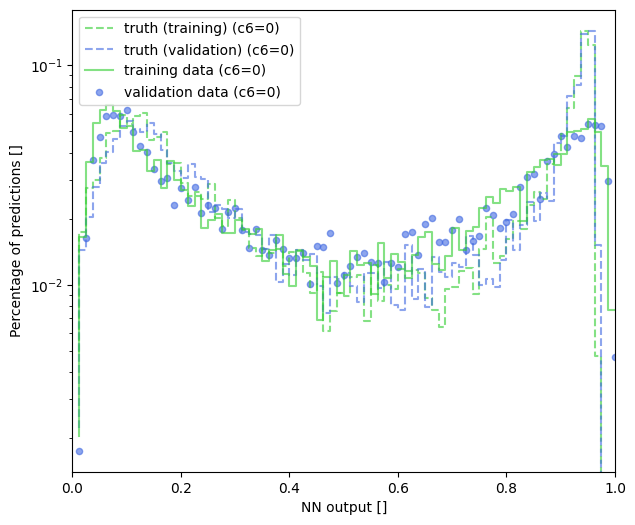

In [86]:
BINS = 80

c6_vals = [0]
colors = ['limegreen', 'royalblue', 'limegreen', 'royalblue']

print(train_data[:,-2].shape)
print(predictions_train.shape)

histograms = generate_histograms(train_data, predictions_train, val_data, predictions_val, BINS)

plot_histograms(c6_vals, histograms, colors, xlim=(0,1.0))

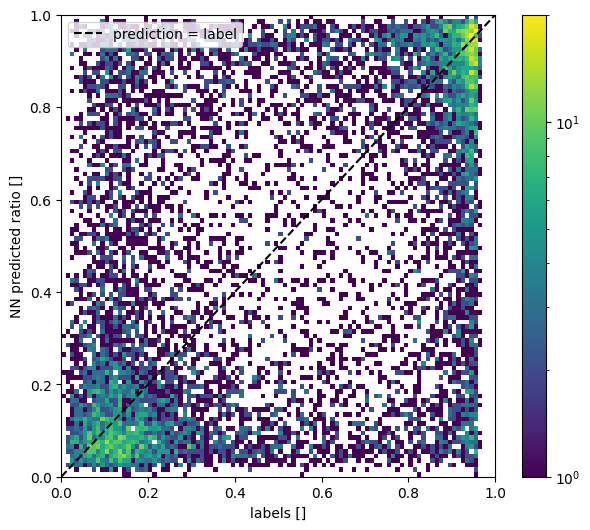

In [95]:
bounds = [0.0,1.0]

c6_val=-10

fig, ax = plt.subplots(figsize=(7,6))

im = ax.hist2d(ratios_training/(1+ratios_training), predictions_train.squeeze(axis=1), bins=100, range=[bounds, bounds], norm=LogNorm(), cmin=0.0)
#im = ax.hist2d(ratios_validation/(1+ratios_validation), predictions_val.squeeze(axis=1), bins=100, range=[bounds, bounds], norm=LogNorm(), cmin=0.0)
ax.plot(np.linspace(*bounds), np.linspace(*bounds), '--', color='k', label='prediction = label')

fig.colorbar(im[3], ax=ax)

plt.xlabel(f'labels []')
plt.ylabel(f'NN predicted ratio []')
plt.legend()

plt.show()

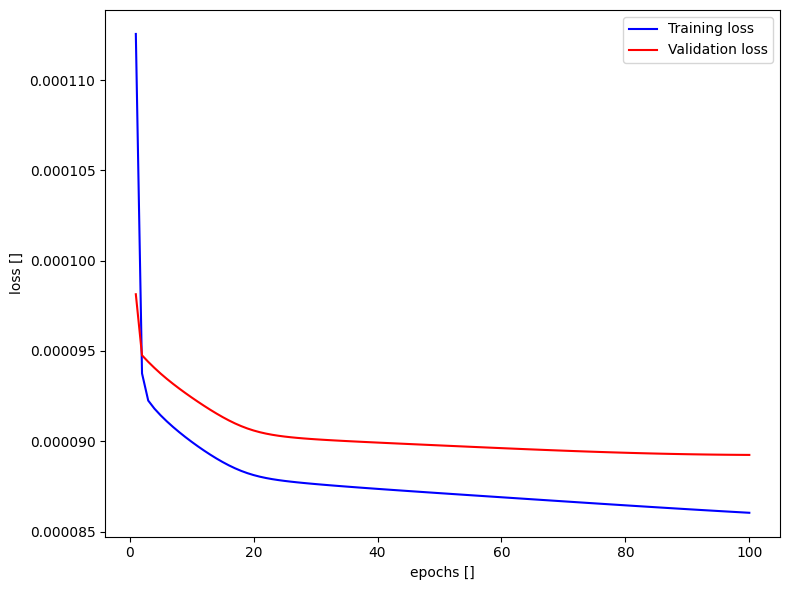

In [93]:
hist_prm = ''

with open(os.path.join(OUTPUT_DIR, 'history.txt'), 'r') as hist_file:
    hist_prm = hist_file.readlines()

hist_prm = [ np.array(el.replace('[','').replace(']','').replace(' ','').split(','), dtype=float) for el in hist_prm[0].split('][')]

t_loss_prm = np.array(hist_prm[0])
v_loss_prm = np.array(hist_prm[1])

epochs = range(1,t_loss_prm.shape[0]+1)

fig = plt.figure(figsize=(8,6))

#ax1.set_xticklabels([])

plt.plot(epochs, t_loss_prm, 'b', label='Training loss')
plt.xlabel('epochs []')
plt.ylabel(f'loss []')
#ax2.legend()

plt.plot(epochs, v_loss_prm, 'r', label='Validation loss')
#ax1.set_ylabel('loss []')
plt.legend()

fig.tight_layout()

plt.show()

In [63]:
JOB_ID = 14725450

JOB_OUT_FILE = os.path.join(OUTPUT_DIR, 'logs', 'job.out.' + str(JOB_ID))

import re

with open(JOB_OUT_FILE, 'r') as log_file:
    logs = ''.join(log_file.readlines())

t_loss = np.array(re.findall("\ loss:\ ([0-9]\.[0-9]+e?-?[0-9]*)\ -", logs)).astype(np.float32)
v_loss = np.array(re.findall("\ val_loss:\ ([0-9]\.[0-9]+e?-?[0-9]*)\ -", logs)).astype(np.float32)

epochs = range(1,t_loss.shape[0]+1)

fig = plt.figure(figsize=(8,6))

#ax1.set_xticklabels([])

plt.plot(epochs, t_loss, 'b', label='Training loss')
plt.xlabel('epochs []')
plt.ylabel(f'loss []')
#ax2.legend()

plt.plot(epochs, v_loss, 'r', label='Validation loss')
#ax1.set_ylabel('loss []')
plt.legend()

fig.tight_layout()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'jobs/carl/gpudev-one-nonprm/logs/job.out.14725450'